
📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

📊 Dataset Description:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.0

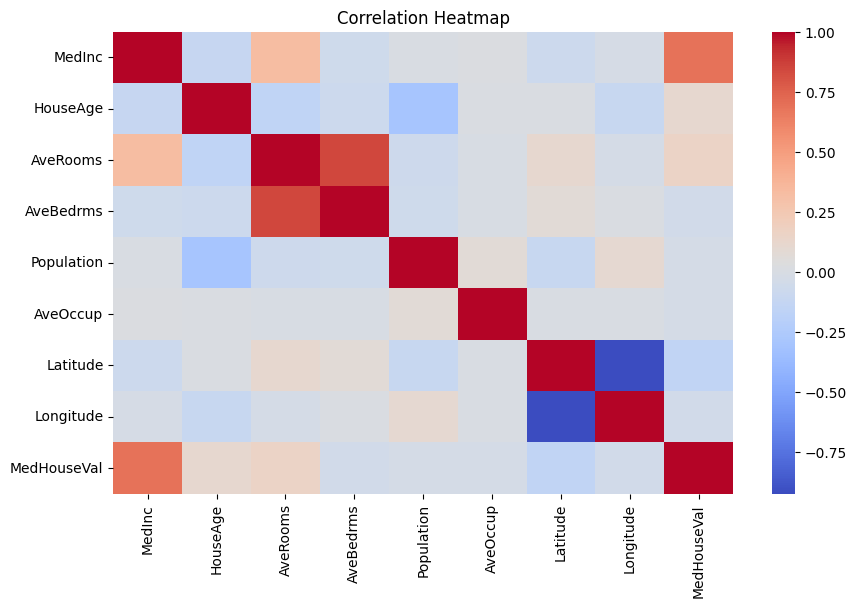


📊 Baseline Results:
           Model       MSE      RMSE       MAE       R²
0  KNN (Default)  0.433811  0.658643  0.445525  0.66895

Cross Validation Score (R²): 0.5237

Best Parameters: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}

📊 Results after Tuning:
           Model       MSE      RMSE       MAE        R²
0  KNN (Default)  0.433811  0.658643  0.445525   0.66895
1    KNN (Tuned)  0.361928  0.601604  0.403459  0.723806


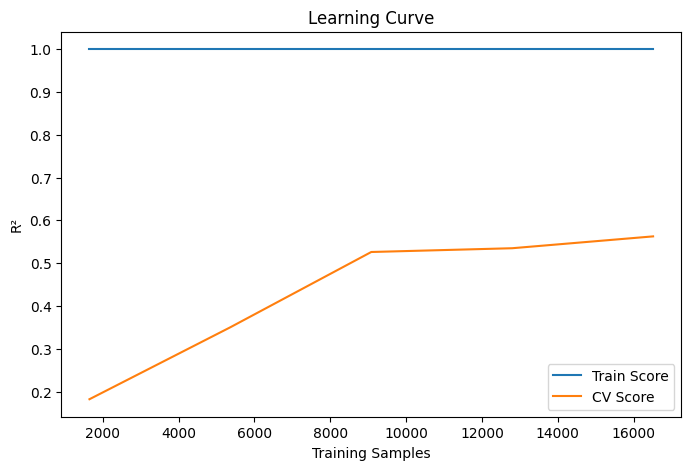

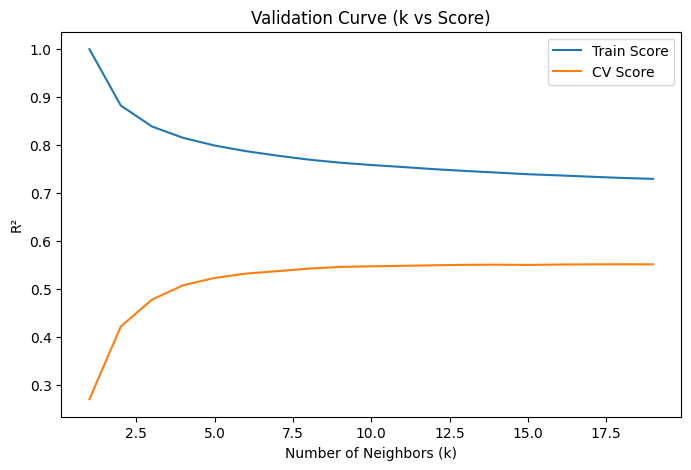

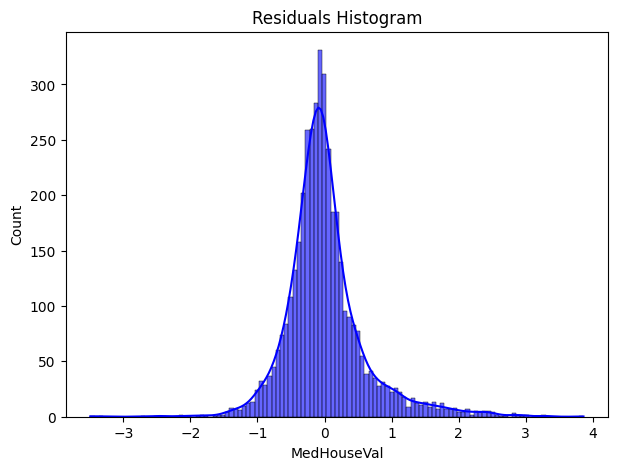

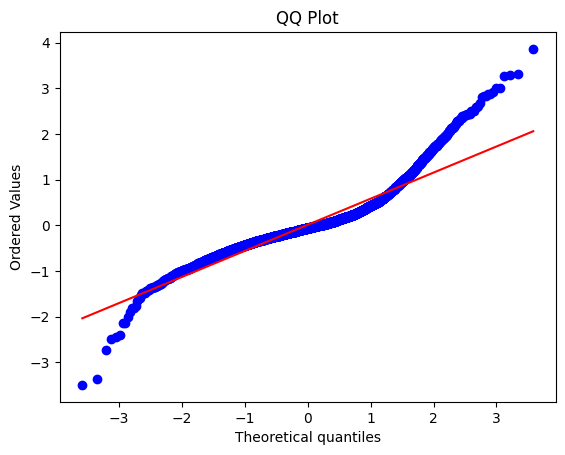

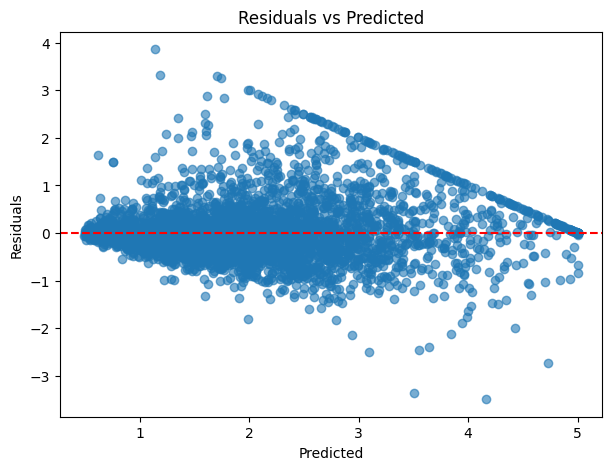

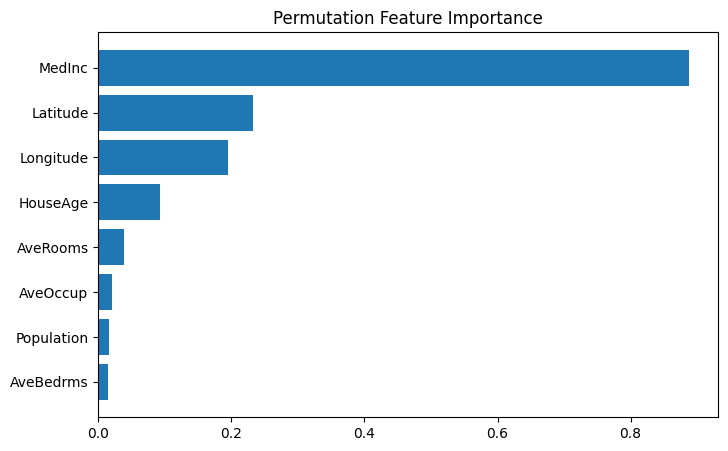

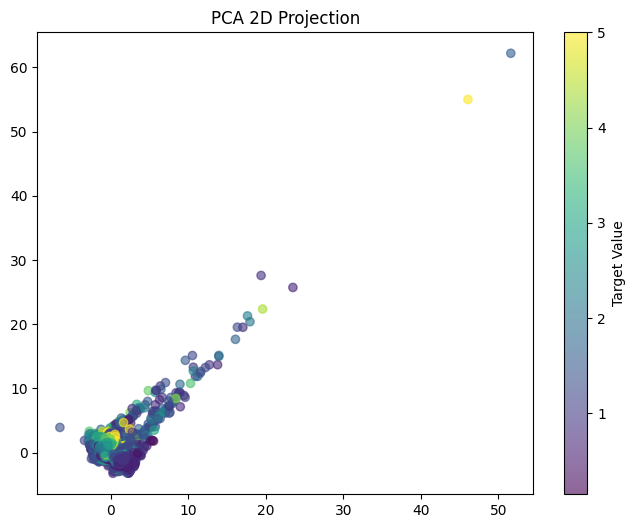

ExactExplainer explainer: 101it [12:46,  7.66s/it]                         


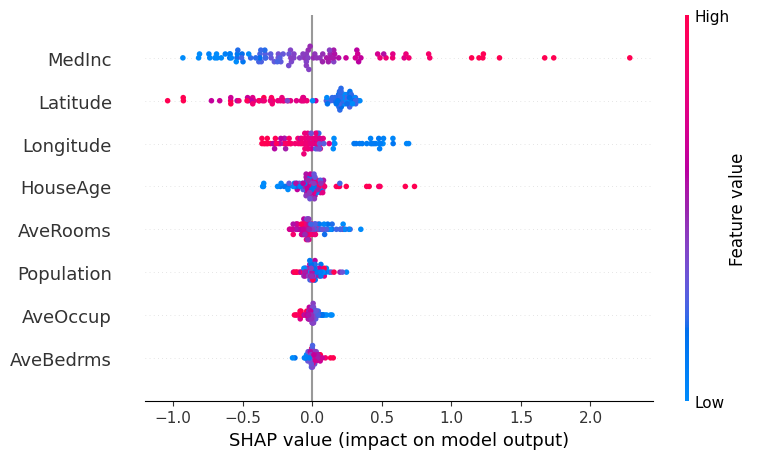


📊 Final Comparison:
              Model       MSE      RMSE       MAE        R²
0     KNN (Default)  0.433811  0.658643  0.445525   0.66895
1       KNN (Tuned)  0.361928  0.601604  0.403459  0.723806
2  KNN (Noisy Data)   0.43189  0.657184   0.44753  0.670416
3      RandomForest  0.255498  0.505468  0.327613  0.805024
4               SVR  0.355198  0.595985  0.397763  0.728941


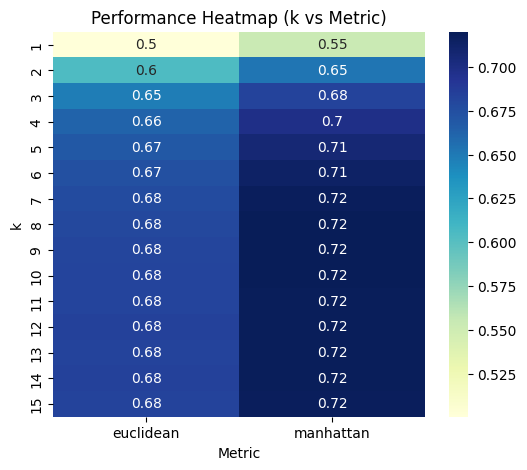


📄 PDF Report generated: KNN_Report.pdf

💻 To run interactive dashboard, use:
streamlit run knn_dashboard.py


In [2]:
# ================================
# 📌 K-Nearest Neighbors Regression 
# Author: Shahinda
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

import shap
import scipy.stats as stats

# PDF Report
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

# -------------------------------
# 1. Load Dataset
# -------------------------------
data = fetch_california_housing(as_frame=True)
df = data.frame

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# -------------------------------
# 2. Exploratory Data Analysis (EDA)
# -------------------------------
print("\n📊 Dataset Info:")
print(df.info())
print("\n📊 Dataset Description:")
print(df.describe())

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 3. Data Preprocessing
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Baseline Model
# -------------------------------
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# -------------------------------
# 5. Evaluation Function
# -------------------------------
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    })

results = pd.DataFrame([
    evaluate_model(y_test, y_pred_knn, "KNN (Default)")
])

print("\n📊 Baseline Results:")
print(results)

# -------------------------------
# 6. Cross Validation
# -------------------------------
knn_cv = cross_val_score(knn, X_scaled, y, cv=5, scoring="r2").mean()
print(f"\nCross Validation Score (R²): {knn_cv:.4f}")

# -------------------------------
# 7. Hyperparameter Tuning
# -------------------------------
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}
grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

best_knn = grid.best_estimator_
print("\nBest Parameters:", grid.best_params_)

y_pred_best = best_knn.predict(X_test)

results = pd.concat([
    results,
    evaluate_model(y_test, y_pred_best, "KNN (Tuned)").to_frame().T
], ignore_index=True)

print("\n📊 Results after Tuning:")
print(results)

# -------------------------------
# 8. Learning Curves
# -------------------------------
train_sizes, train_scores, test_scores = learning_curve(
    best_knn, X_scaled, y, cv=5, scoring="r2"
)
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="CV Score")
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Learning Curve")
plt.legend()
plt.show()

# -------------------------------
# 9. Validation Curve (k vs Score)
# -------------------------------
param_range = range(1, 20)
train_scores, test_scores = validation_curve(
    KNeighborsRegressor(), X_scaled, y,
    param_name="n_neighbors", param_range=param_range,
    cv=5, scoring="r2"
)
plt.figure(figsize=(8,5))
plt.plot(param_range, train_scores.mean(axis=1), label="Train Score")
plt.plot(param_range, test_scores.mean(axis=1), label="CV Score")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("R²")
plt.title("Validation Curve (k vs Score)")
plt.legend()
plt.show()

# -------------------------------
# 10. Residual & Error Analysis
# -------------------------------
residuals = y_test - y_pred_best

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, color="blue", alpha=0.6)
plt.title("Residuals Histogram")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# -------------------------------
# 11. Robustness Test with Noise
# -------------------------------
X_noisy = X_train + np.random.normal(0, 0.1, X_train.shape)
best_knn.fit(X_noisy, y_train)
noise_pred = best_knn.predict(X_test)

results = pd.concat([
    results,
    evaluate_model(y_test, noise_pred, "KNN (Noisy Data)").to_frame().T
], ignore_index=True)

# -------------------------------
# 12. Permutation Feature Importance
# -------------------------------
perm_importance = permutation_importance(best_knn, X_test, y_test, n_repeats=10)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(8,5))
plt.barh(np.array(data.feature_names)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance")
plt.show()

# -------------------------------
# 13. PCA Visualization
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", alpha=0.6)
plt.colorbar(label="Target Value")
plt.title("PCA 2D Projection")
plt.show()

# -------------------------------
# 14. SHAP Values
# -------------------------------
import shap

explainer = shap.Explainer(best_knn.predict, X_test)
shap_values = explainer(X_test[:100])

shap.summary_plot(shap_values, features=X_test[:100], feature_names=data.feature_names)
# -------------------------------
# 15. Compare with RandomForest + SVR
# -------------------------------
rf = RandomForestRegressor(random_state=42)
svr = SVR()

rf.fit(X_train, y_train)
svr.fit(X_train, y_train)

results = pd.concat([
    results,
    evaluate_model(y_test, rf.predict(X_test), "RandomForest").to_frame().T,
    evaluate_model(y_test, svr.predict(X_test), "SVR").to_frame().T
], ignore_index=True)

print("\n📊 Final Comparison:")
print(results)

# -------------------------------
# 16. Heatmap (k vs distance metric)
# -------------------------------
metrics = ["euclidean", "manhattan"]
heatmap_scores = []
for k in range(1, 16):
    row = []
    for m in metrics:
        model = KNeighborsRegressor(n_neighbors=k, metric=m)
        model.fit(X_train, y_train)
        score = r2_score(y_test, model.predict(X_test))
        row.append(score)
    heatmap_scores.append(row)

heatmap_scores = np.array(heatmap_scores)

plt.figure(figsize=(6,5))
sns.heatmap(heatmap_scores, annot=True, xticklabels=metrics, yticklabels=range(1,16), cmap="YlGnBu")
plt.title("Performance Heatmap (k vs Metric)")
plt.xlabel("Metric")
plt.ylabel("k")
plt.show()

# -------------------------------
# 17. Automated PDF Report
# -------------------------------
doc = SimpleDocTemplate("KNN_Report.pdf")
styles = getSampleStyleSheet()
story = []

story.append(Paragraph("K-Nearest Neighbors Regression Report", styles["Title"]))
story.append(Spacer(1, 12))
story.append(Paragraph("This report summarizes model evaluation, tuning, and comparisons.", styles["Normal"]))
story.append(Spacer(1, 12))
story.append(Paragraph(str(results), styles["Code"]))
doc.build(story)

print("\n📄 PDF Report generated: KNN_Report.pdf")

# -------------------------------
# 18. Streamlit Demo (for deployment)
# -------------------------------
print("\n💻 To run interactive dashboard, use:")
print("streamlit run knn_dashboard.py")

with open("knn_dashboard.py", "w") as f:
    f.write('''
import streamlit as st
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

data = fetch_california_housing(as_frame=True)
df = data.frame
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

st.title("KNN Regression Dashboard")
k = st.slider("Choose k:", 1, 20, 5)

model = KNeighborsRegressor(n_neighbors=k)
model.fit(X_train, y_train)

score = model.score(X_test, y_test)
st.write(f"R² Score: {score:.4f}")
    ''')